<div align="center">
  <img src="assets/title.png" width="1200">
</div>

# Quantum Variational Circuits: 2-Pixel Line Detection

## What You'll Learn
In this workshop, we will tackle a fundamental computer vision problem using a Variational Quantum Classifier (VQC). 

By the end of this hands-on workshop, you will:

*  Understand basic quantum computing concepts (qubits, gates, circuits)
*  Build a Quantum Neural Network (QNN) from scratch
*  Train your QNN to classify 2-pixel line patterns
*  Visualize and interpret quantum machine learning results

## ⚠️ Disclaimer & Goals

This session is not designed to master all QML concepts in 45 minutes. Instead, our goal is to provide a **practical overview** and a **launchpad for your quantum journey**, demonstrating that "quantum" is happening right now.

### How to Use This Notebook

**A Starting Point:** Think of this as a live roadmap rather than a textbook.

**Learn at Your Own Pace:** You are encouraged to use this notebook for continued study after the session.

**Deep Dives:** Throughout the notebook, you will find **📚 Advanced Sections** containing extra topics and technical deep-dives. These didn't fit into our 45-minute window, but they are there for you to explore independently when you're ready to level up.

---

##  Quantum Computing Basics

### Qubits: The Building Blocks

**Classical bit:** Either 0 OR 1 (like a light switch)

**Qubit:** Can be 0 AND 1 simultaneously (**superposition**)

**Mathematical representation:**
$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle = \begin{bmatrix} \alpha \\ \beta \end{bmatrix}$$

Where $|\alpha|^2$ = probability of measuring 0, $|\beta|^2$ = probability of measuring 1.

**Example:** $|\psi\rangle = 0.8|0\rangle + 0.6|1\rangle = \begin{bmatrix} 0.8 \\ 0.6 \end{bmatrix}$ → 64% chance of |0⟩, 36% chance of |1⟩


---

### Quantum Gates: Operations on Qubits

Quantum gates transform qubit states (like rotations):

**Single-Qubit Gates:**

- **RX(θ), RY(θ), RZ(θ)** — Rotation gates (trainable parameters in QNNs)
- **H (Hadamard)** — Creates equal superposition: $|0\rangle \rightarrow \frac{|0\rangle + |1\rangle}{\sqrt{2}}$
- **X, Y, Z (Pauli)** — Bit flips and phase shifts

**Two-Qubit Gate:**

- **CNOT** — Creates entanglement between qubits
  - If control = |1⟩ → flip target
  - If control = |0⟩ → do nothing

💡 Entanglement - a connection between two qubits where measuring one immediately reveals information about the other, no matter the distance, because their states are fundamentally linked.

---

### Quantum Circuit Example

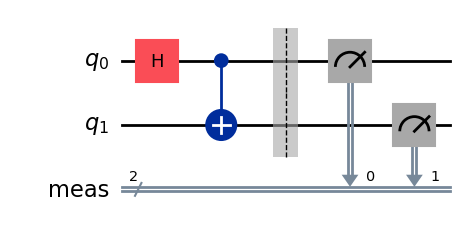

In [118]:
from qiskit import QuantumCircuit

# Create a simple 2-qubit circuit
qc = QuantumCircuit(2)
qc.h(0)           # Hadamard on qubit 0
qc.cx(0, 1)       # CNOT: control=0, target=1
qc.measure_all()  # Measure both qubits

# Visualize
qc.draw('mpl')

---

##  ⚛ Moving to Quantum Machine Learning

### The QML Workflow: From Circuit to Result
1. **Data Encoding & Circuit Design:** Map classical datasets into quantum feature maps and construct a parameterized circuit.
2. **Hardware Tailoring:** Transpile and compile the abstract circuit to match the specific connectivity, gate set, and noise profile of the target quantum processor.
3. **Training & Inference:** Use Qiskit Runtime Primitives to execute iterative training loops and perform final model inference for prediction generation.
4. **Analysis & Evaluation:** Post-process the output data to visualize loss curves and calculate final classification accuracy to determine model performance.


<div align="center">
  <img src="assets/qml_workflow.png" width="800">
</div>

### The Challenge

We will train our quantum model to differentiate between two types of features on a $2 \times 4$ pixel grid:
* **Horizontal Lines:** A row of 2 illuminated pixels.
* **Vertical Lines:** A column of 2 illuminated pixels.

Crucially, both shapes contain exactly the same amount of "light" (2 pixels), and they can appear anywhere on the grid. The quantum computer cannot simply memorize pixel locations or measure total brightness; it must learn the spatial correlation of the shapes themselves.

## Data generation

#### We define a dataset where 2-pixel lines can appear in any valid position on the $2 \times 4$ grid. We also add background noise to make the classification a true machine learning challenge.

In [119]:
# Standard library imports
import os
from dotenv import load_dotenv

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import XGate, z_feature_map
from qiskit.primitives import BaseEstimatorV2, StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info.operators.base_operator import BaseOperator
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    ALAPScheduleAnalysis,
    ConstrainedReschedule,
    PadDynamicalDecoupling,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

print("All imports loaded successfully")


All imports loaded successfully


In [120]:
# Dataset Configuration
size = 8  # Total pixels per image (will be encoded as qubits)
vert_size = 2  # Image height in pixels
hor_size = round(size / vert_size)  # Image width (4 pixels)
line_size = 2  # Length of lines to detect

def generate_dataset(num_images):

    images = []
    labels = []
    
    # Pre-calculate all possible line positions
    hor_array = np.zeros((size - (line_size - 1) * vert_size, size))
    ver_array = np.zeros((round(size / vert_size) * (vert_size - line_size + 1), size))

    # Generate horizontal line templates
    j = 0
    for i in range(0, size - 1):
        if i % (size / vert_size) <= (size / vert_size) - line_size:
            for p in range(0, line_size):
                hor_array[j][i + p] = np.pi / 2
            j += 1

    # Generate vertical line templates
    j = 0
    for i in range(0, round(size / vert_size) * (vert_size - line_size + 1)):
        for p in range(0, line_size):
            ver_array[j][i + p * round(size / vert_size)] = np.pi / 2
        j += 1

    # Create random images
    for n in range(num_images):
        rng = np.random.randint(0, 2)
        if rng == 0:
            labels.append(-1)  # Horizontal
            random_image = np.random.randint(0, len(hor_array))
            images.append(np.array(hor_array[random_image]))
        elif rng == 1:
            labels.append(1)  # Vertical
            random_image = np.random.randint(0, len(ver_array))
            images.append(np.array(ver_array[random_image]))

        # Add noise to background pixels
        for i in range(size):
            if images[-1][i] == 0:
                images[-1][i] = np.random.rand() * np.pi / 4
                
    return np.array(images), labels

# Generate 200 images and split 70/30 train/test
np.random.seed(42)
images, labels = generate_dataset(200)
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.3, random_state=246
)


#### Plot the images

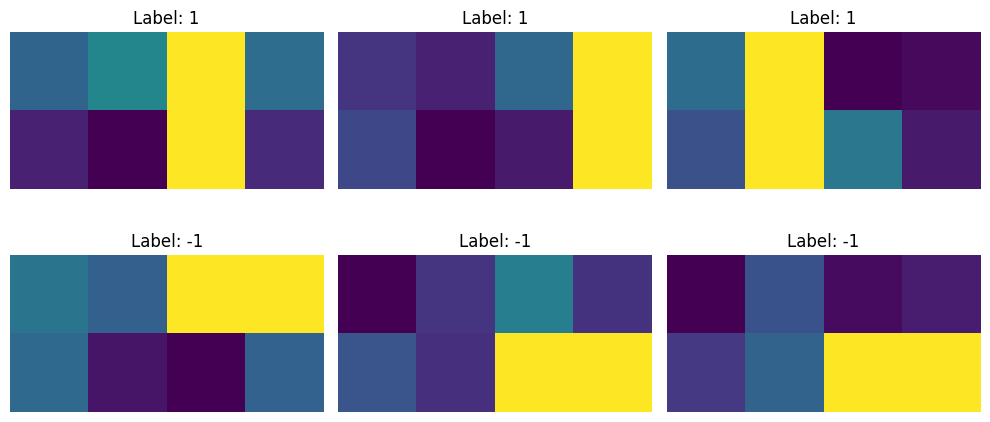

In [121]:
fig, ax = plt.subplots(2, 3, figsize=(10, 5))

# Convert labels to numpy array if needed
train_labels_array = np.array(train_labels)

# Get indices for each label
label_1_indices = np.where(train_labels_array == 1)[0]
label_minus1_indices = np.where(train_labels_array == -1)[0]

# First row: 3 random samples with label 1 (vertical)
for i in range(3):
    idx = np.random.choice(label_1_indices)
    ax[0, i].imshow(train_images[idx].reshape(vert_size, hor_size), cmap='viridis')
    ax[0, i].set_title(f"Label: {train_labels[idx]}")
    ax[0, i].axis('off')

# Second row: 3 random samples with label -1 (horizontal)
for i in range(3):
    idx = np.random.choice(label_minus1_indices)
    ax[1, i].imshow(train_images[idx].reshape(vert_size, hor_size), cmap='viridis')
    ax[1, i].set_title(f"Label: {train_labels[idx]}")
    ax[1, i].axis('off')

plt.tight_layout()
plt.show()


## 1. **Data Encoding & Circuit Design:**

#### To bridge the gap between classical data and quantum computation, we define a function $f_{\theta}(\vec{x})$ that processes an input vector $\vec{x}$ (like image pixels) to produce a classification label. This is the heart of a Variational Quantum Circuit (VQC).

<div align="center">
  <img src="assets/qml_formula.png" width="600">
</div>


#### Think of this process as a three-stage quantum pipeline:

**The Feature Map $U(\vec{x})$:** This "loads" your classical data into quantum states. By applying data-dependent rotations, we move from a simple $|0\rangle$ state into a complex high-dimensional Hilbert space where patterns might be easier to separate.

**The Ansatz $W(\theta)$:** This is the "brain" of your circuit. It consists of tunable quantum gates (parameters $\theta$) that we adjust—much like weights in a classical neural network—to find the optimal transformation for our specific task.

**The Observable $O$:** Finally, we perform a measurement. By calculating the expectation value of an operator $O$, we collapse the quantum information back into a classical number that tells us whether the result is a $+1$ or a $-1$.

<details>
<summary>📚 <b>Advanced: Understanding the Dagger (†) Operator</b></summary>

In our QNN formula:

$$f_\theta(\vec{x}) = \langle 0 | U^\dagger(\vec{x}) \, W^\dagger(\theta) \, O \, W(\theta) \, U(\vec{x}) | 0 \rangle$$

The **† (dagger)** represents the **conjugate transpose** of a quantum operation—essentially running the circuit backwards.

### Why Do We Need It?

**The Sandwich Structure:** Notice how the formula "sandwiches" the observable $O$ between forward operations $W(\theta)U(\vec{x})$ and their daggers $U^\dagger(\vec{x})W^\dagger(\theta)$.

This creates a **unitary transformation** that:

1. **Encodes data** → $U(\vec{x})|0\rangle$
2. **Applies learning** → $W(\theta)$
3. **Measures in transformed basis** → $O$
4. **Reverses transformation** → $W^\dagger(\theta)U^\dagger(\vec{x})$

### The Key Insight

Without the dagger operations, we'd just be measuring in the computational basis. The sandwich structure lets us measure **how much the circuit changed the state** relative to the starting point—this is what gives us the prediction!

**Think of it as:** Forward → Measure → Rewind = "How far did we travel?"

**Deep dive:** [IBM Quantum - Unitary Operations](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/multiple-systems/quantum-information#unitary-operations)

</details>


#### Now, we need to address a fundamental challenge:  
A quantum computer cannot "see" classical data. It doesn't understand pixels, spreadsheets, or raw numbers in their native format. To a quantum processor, your image is just a collection of classical bits, but it needs to work with quantum states.
This is where **Data Encoding** steps in. It acts as the translator that "uploads" your classical vector $\vec{x}$ into the vast, high-dimensional Hilbert space of the qubits.
In this workshop, we use the [**Z Feature Map**](https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/data-encoding#z-feature-map) to perform this translation. Each feature in your input vector is encoded as a rotation on a qubit around the Z-axis, so the number of qubits determines how many features we can encode at once. For our dataset, one qubit per feature is sufficient, which keeps the circuit simple and efficient while capturing all the information we need for learning.

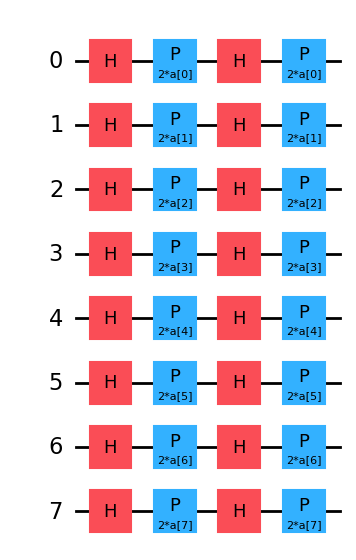

In [122]:
# One qubit per data feature
num_qubits = len(train_images[0])

# Data encoding
# Note that qiskit orders parameters alphabetically. We assign the parameter prefix "a" to ensure our data encoding goes to the first part of the circuit, the feature mapping.
feature_map = z_feature_map(num_qubits, parameter_prefix="a")
feature_map.draw(output='mpl')

## Choosing an Ansatz ⚛

Now that our data is encoded into a quantum state, we need a way to **process and learn from it**.

This is where the **Ansatz** comes in.

The Ansatz is a parameterized quantum circuit with tunable parameters $\theta$ (like weights in a neural network).

In this workshop, we use:

- **Rotation gates (RY, RX)** — they "rotate" the qubit state, changing its value in a controllable way (this is how we introduce learnable parameters). For now, you can think of this step simply as an operation that adjusts the qubit based on $\theta$.  
- **CNOT gates** — they connect qubits together, allowing them to share information. For now, think of this as an operation that lets qubits influence each other.
- 
Together, these let the circuit learn patterns in the data.

---

💡 When choosing an ansatz:

- keep it **simple** (hardware is noisy)  
  Quantum computers are error-prone, so deeper circuits (especially with many two-qubit gates) can quickly degrade results. Simpler circuits are usually more reliable.

- match the **problem structure**  
  Try to design the circuit in a way that reflects your data. For example, for images, it makes sense to connect **neighboring qubits**, since nearby pixels are often related.

- avoid too many **parameters**  
  More parameters give more flexibility, but also make training slower and harder. A smaller, well-structured ansatz is often easier to optimize.

Let’s build it 👇

3
2+ qubit depth: 1

📊 Entanglement Pattern Visualization:
Image Layout (2×4 pixels = 8 qubits):
  Top row:    [Q0] [Q1] [Q2] [Q3]
               ↓    ↓    ↓    ↓
  Bottom row: [Q4] [Q5] [Q6] [Q7]

CNOT Connections (↓ indicates entanglement):
  Column 0: Q0 ↓ Q4
  Column 1: Q1 ↓ Q5
  Column 2: Q2 ↓ Q6
  Column 3: Q3 ↓ Q7

✓ Vertical neighbors are entangled (between rows)
✗ No horizontal entanglement within rows


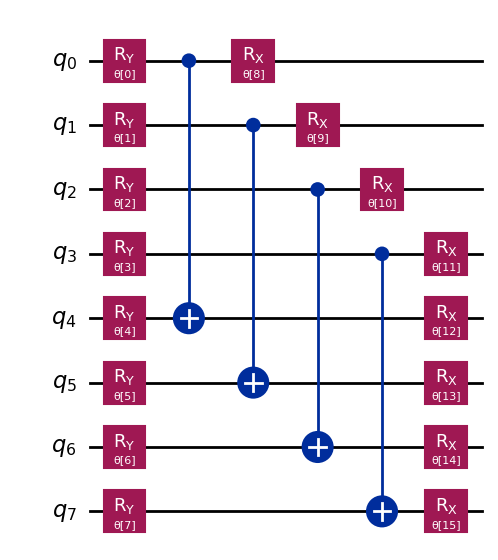

In [123]:
# Import the necessary packages
from qiskit import QuantumCircuit

# Initialize the circuit using the same number of qubits as the image has pixels
qnn_circuit = QuantumCircuit(size)

# We choose to have two variational parameters for each qubit.
params = ParameterVector("θ", length=2 * size)

# A first variational layer:
for i in range(size):
    qnn_circuit.ry(params[i], i)

# Entanglement pattern: Connect VERTICALLY adjacent qubits between rows
# Image structure:  [0][1][2][3]  ← Top row (qubits 0-3)
#                    ↓  ↓  ↓  ↓
#                   [4][5][6][7]  ← Bottom row (qubits 4-7)
# 
# CNOTs create "communication" between pixels in the same column,
# allowing the circuit to detect VERTICAL line patterns.
qnn_cnot_list = [[0, 4], [1, 5], [2, 6], [3, 7]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])

# The second variational layer:
for i in range(size):
    qnn_circuit.rx(params[size + i], i)

# Check the circuit depth, and the two-qubit gate depth
print(qnn_circuit.decompose().depth())
print(
    f"2+ qubit depth: {qnn_circuit.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Visualize the entanglement pattern
print("\n📊 Entanglement Pattern Visualization:")
print("=" * 50)
print("Image Layout (2×4 pixels = 8 qubits):")
print("  Top row:    [Q0] [Q1] [Q2] [Q3]")
print("               ↓    ↓    ↓    ↓")
print("  Bottom row: [Q4] [Q5] [Q6] [Q7]")
print("\nCNOT Connections (↓ indicates entanglement):")
print("  Column 0: Q0 ↓ Q4")
print("  Column 1: Q1 ↓ Q5")
print("  Column 2: Q2 ↓ Q6")
print("  Column 3: Q3 ↓ Q7")
print("\n✓ Vertical neighbors are entangled (between rows)")
print("✗ No horizontal entanglement within rows")
print("=" * 50)

# Draw the circuit
qnn_circuit.draw("mpl")


## Building the Full Quantum Model

Now we combine everything together.

We take:
- the **feature map $U(\vec{x})$** (data encoding)  
- the **ansatz $W(\theta)$** (trainable circuit)  

and stack them into a single quantum circuit.

This is very similar to a neural network:
- input layer → $U(\vec{x})$  
- trainable layers → $W(\theta)$  

Together, they form our **Quantum Neural Network (QNN)**.

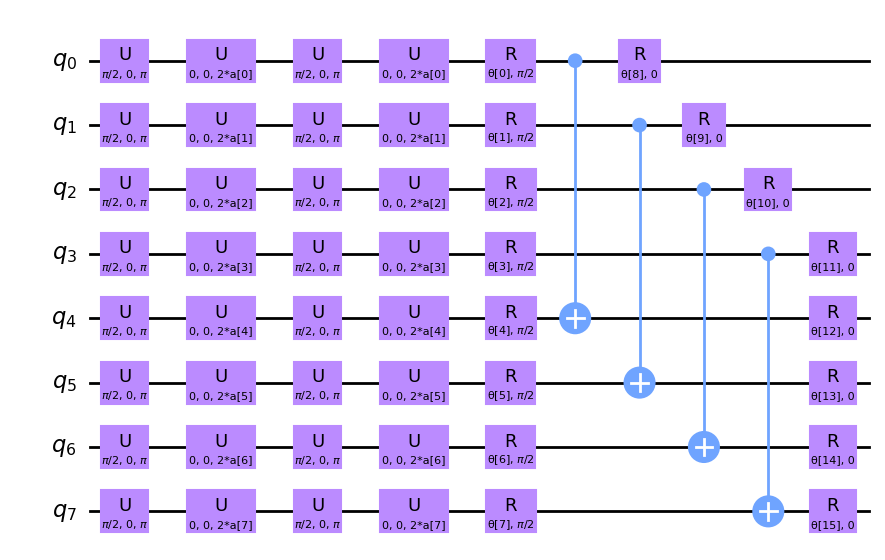

In [124]:
# QNN ansatz
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

## 🎉 Congratulations!

You’ve just built your **Variational Quantum Circuit (VQC)**!  

But don’t think that’s the end - this is only the **model structure**. Next, we need to prepare the code to **train the VQC and make it learn from our data**, so it can actually start solving the task.

### Defining the Observable 

Next, we define an **observable**, which is an operator we can measure on the quantum circuit to get a classical number. Here, we use a `Z` operator on each qubit. Technically, this means we are measuring in the [Pauli Z basis]('https://quantum.cloud.ibm.com/learning/en/courses/foundations-of-quantum-error-correction/stabilizer-formalism/pauli-operations-and-observables'), which gives eigenvalues of +1 or -1. For our binary classification task, each qubit carries information about the input, and measuring all of them produces a value we can feed into the cost function to guide training.

In [125]:
observable = SparsePauliOp.from_list([("Z" * (num_qubits), 1)])

Before we can train our quantum neural network, we need a way to get outputs from the circuit. That’s what the **forward pass** does.  

The function takes `input_params` and `weight_params` separately. The `input_params` represent the data we want to encode, like image pixels, and the `weight_params` are the tunable parameters of the ansatz that will be optimized.  

In [126]:
def forward(
    circuit: QuantumCircuit,
    input_params: np.ndarray,
    weight_params: np.ndarray,
    estimator: BaseEstimatorV2,
    observable: BaseOperator,
) -> np.ndarray:
    """
    Forward pass of the neural network.

    Args:
        circuit: circuit consisting of data loader gates and the neural network ansatz.
        input_params: data encoding parameters.
        weight_params: neural network ansatz parameters.
        estimator: EstimatorV2 primitive.
        observable: a single observable to compute the expectation over.

    Returns:
        expectation_values: an array (for one observable) or a matrix (for a sequence of observables) of expectation values.
        Rows correspond to observables and columns to data samples.
    """
    num_samples = input_params.shape[0]
    weights = np.broadcast_to(weight_params, (num_samples, len(weight_params)))
    params = np.concatenate((input_params, weights), axis=1)
    pub = (circuit, observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    expectation_values = result.data.evs

    return expectation_values

### How does our QNN learn? 🤔

Now we bring in classical methods. To train our model, we need a **loss function** that tells us how well the QNN is performing.

The loss function compares the predicted labels from our model with the true labels and measures the difference between them. In our case, we use **Mean Squared Error (MSE)**, which simply computes the average of the squared differences.

There are many possible loss functions, but MSE is a simple and effective choice for our example.

In [127]:
def mse_loss(predict: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Mean squared error (MSE).

    prediction: predictions from the forward pass of neural network.
    target: true labels.

    output: MSE loss.
    """
    if len(predict.shape) <= 1:
        return ((predict - target) ** 2).mean()
    else:
        raise AssertionError("input should be 1d-array")

## Optimizing the Problem for Quantum Execution

We start by selecting a backend for execution. In this notebook we pin to `ibm_fez` so the transpilation result matches the cached hardware run shown later.


Now it’s your turn to try this on a **real quantum computer**

To do that, you’ll need an **IBM Quantum API key**:
- Go to the [IBM Quantum portal](https://quantum.cloud.ibm.com/)
- Create an account (if you don’t have one) 
- Copy your API key and connect it in your environment 

You get **free access to real quantum hardware (10 minutes)**, which is perfect for testing your circuits.

## Setting Up Your IBM Quantum API Key

After creating your API key, we need to **store it securely** and connect to IBM Quantum.

Create a `.env` file in the project root and store your key as an environment variable:

Paste your key inside it using this exact format:

```
IBM_QUANTUM_API_KEY=your_api_key_here
```

In [128]:
# Load variables from .env file
load_dotenv()
api_key = os.getenv("IBM_QUANTUM_API_KEY")

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=api_key,
    overwrite=True
)

We pin the backend to `ibm_fez` explicitly so the transpilation result lines up with the cached hardware run shown later in this notebook. `service.least_busy()` is the idiomatic choice when you just want the shortest queue — see the Qiskit docs for that path.


In [129]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.backend("ibm_fez")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-04-09 13:07:06,578: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-09 13:07:06,579: Using instance: open-instance, plan: open


ibm_fez


## Optimizing the Circuit for Real Hardware

Before running on a real quantum computer, we need to **adapt (transpile) our circuit** to match the hardware.

Real devices have constraints:
- specific qubit connections  
- limited gate sets  
- noise and decoherence  

In the code below, we:
- set a high **optimization level (3)** to simplify and improve the circuit  
- apply **scheduling** to organize when gates are executed  
- add **dynamical decoupling**, which inserts extra gates to help protect qubits from noise  

Don’t worry if this part feels a bit advanced - that’s totally normal. These are lower-level optimizations that you’ll understand better with more experience. For now, just think of this step as **preparing your circuit to run reliably on real hardware**.

In [130]:
# Get hardware-specific information (gate set, connectivity, timing constraints)
target = backend.target

# Generate a preset pass manager with a high optimization level
# This will simplify the circuit and adapt it to the hardware
pm = generate_preset_pass_manager(target=target, optimization_level=3)

# Add a custom scheduling step to further optimize execution timing
pm.scheduling = PassManager(
    [
        # Schedule operations as late as possible (reduces idle time at the end)
        ALAPScheduleAnalysis(target=target),

        # Adjust timing to satisfy hardware alignment constraints
        ConstrainedReschedule(
            acquire_alignment=target.acquire_alignment,
            pulse_alignment=target.pulse_alignment,
            target=target,
        ),

        # Insert extra X gates during idle periods to reduce noise (dynamical decoupling)
        PadDynamicalDecoupling(
            target=target,
            dd_sequence=[XGate(), XGate()],  # simple XX sequence
            pulse_alignment=target.pulse_alignment,
        ),
    ]
)

## Applying the Pass Manager

Now we apply the **pass manager** to our full circuit. This adjusts the circuit layout and optimizes it for the target backend.

It’s important to also apply the same layout changes to the **observable**, so measurements match the new qubit arrangement.

For very large circuits, the heuristics used during optimization may not always produce the shallowest or most efficient circuit. In those cases, running the pass manager multiple times and selecting the best result can help — something we’ll explore when we scale up.


In [131]:
# Apply the pass manager to optimize the full circuit
circuit_ibm = pm.run(full_circuit)

# Apply the resulting layout to the observable as well
observable_ibm = observable.apply_layout(circuit_ibm.layout)

print(f"Abstract circuit depth: {full_circuit.decompose().depth()}")
print(f"Transpiled depth on {backend.name}: {circuit_ibm.depth()}")

Abstract circuit depth: 7
Transpiled depth on ibm_fez: 17


## Training the classifier

Training a variational quantum classifier looks almost exactly like training a neural network: pick a loss function, hand it to an optimizer, and let the optimizer hunt for parameters that drive the loss down. The only structural difference is *who runs the forward pass*. In a neural net, the forward pass is matrix multiplications on a CPU or GPU. In a VQC, the forward pass is a quantum circuit running on a quantum processor (or its simulator). Everything else — the loss computation, the parameter update, the bookkeeping — still runs on a regular classical computer.

That gives you a hybrid loop where the two machines pass data back and forth:

```
    classical optimizer  ──▶proposes parameters θ──▶  quantum circuit
          ▲                                                │
          │                                                ▼
          └───────loss value L(θ)<──────  measurement (expectation values)
```

Each iteration: the classical optimizer proposes a new $\theta$, the quantum circuit is evaluated on every training image with that $\theta$, the resulting expectation values are compared to the true labels through the loss, and the optimizer uses the loss number to decide which $\theta$ to try next.

**Math aside — the loss.** We use plain mean squared error against the labels:

$$\mathcal{L}(\theta) \;=\; \frac{1}{N}\sum_{i=1}^{N}\Big(\langle Z^{\otimes 8}\rangle_{\psi(x_i,\theta)} \;-\; y_i\Big)^2$$

The labels are $y_i \in \{-1, +1\}$ rather than the more familiar $\{0, 1\}$. That is not arbitrary: $\langle Z^{\otimes 8}\rangle$ naturally lives in $[-1, +1]$, so matching the label range to the observable range makes the loss landscape symmetric around the decision boundary at zero. Use $\{0, 1\}$ instead and you have to bolt on a rescaling layer that buys you nothing.

### The training loop

We are about to run a small *live* slice of the training loop: 10 iterations of COBYLA on a 20-sample mini-batch. That is enough for the audience to see the optimizer actually working — loss numbers shrinking, parameters updating — without burning workshop minutes on a full training run. After the live demo we load the fully converged weights from cache and pick up from there.

**Why COBYLA, not Adam or SGD?** COBYLA (Constrained Optimization BY Linear Approximation) is a *gradient-free* simplex-style method. It does not need $\nabla_\theta \mathcal{L}$ — it just probes the loss at a small set of test points and fits a local linear model to decide where to move next. That matters here because computing gradients of a quantum circuit is genuinely expensive: the standard technique is the **parameter-shift rule**, which evaluates the circuit at $\theta_k + \pi/2$ and $\theta_k - \pi/2$ for *every* parameter to recover one gradient component. With $P = 16$ parameters that is $2P = 32$ extra circuit runs *per optimizer step*, each run consuming queue time and shot budget on real hardware. A gradient-free optimizer pays $\mathcal{O}(1)$ extra evaluations per step instead of $\mathcal{O}(P)$, which is the right trade-off when each evaluation is a quantum job.

**A taste, not a training run.** Ten iterations on twenty samples will only nudge the loss; do not expect convergence here. The point is to make the hybrid loop *visible*.

In [132]:
import json

estimator = Estimator()

np.random.seed(42)
initial_weights = np.random.rand(2 * num_qubits) * 2 * np.pi

demo_batch_x = train_images[:20]
demo_batch_y = np.array(train_labels[:20])
demo_losses = []


def demo_cost(weights):
    pred = forward(full_circuit, demo_batch_x, weights, estimator, observable)
    loss = mse_loss(pred, demo_batch_y)
    demo_losses.append(loss)
    print(f'  Iteration {len(demo_losses):2d}: loss = {loss:.4f}')
    return loss


print('Running 10 live COBYLA iterations on a 20-sample mini-batch...')
res = minimize(demo_cost, initial_weights, method='COBYLA', options={'maxiter': 10})
print(f'\nLive demo complete. Initial loss: {demo_losses[0]:.4f}, final: {demo_losses[-1]:.4f}')

Running 10 live COBYLA iterations on a 20-sample mini-batch...
  Iteration  1: loss = 0.9982
  Iteration  2: loss = 0.9994
  Iteration  3: loss = 0.9998
  Iteration  4: loss = 0.9980
  Iteration  5: loss = 0.9979
  Iteration  6: loss = 0.9999
  Iteration  7: loss = 0.9994
  Iteration  8: loss = 0.9971


/Users/artem/Documents/GitHub/Quantum-Neural-Network-Workshop/.venv/lib/python3.11/site-packages/scipy/_lib/pyprima/common/preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 18
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')


  Iteration  9: loss = 0.9962
  Iteration 10: loss = 1.0031
  Iteration 11: loss = 1.0005
  Iteration 12: loss = 0.9992
  Iteration 13: loss = 1.0114
  Iteration 14: loss = 0.9905
  Iteration 15: loss = 0.9897
  Iteration 16: loss = 1.0002
  Iteration 17: loss = 0.9742
  Iteration 18: loss = 0.9613

Live demo complete. Initial loss: 0.9982, final: 0.9613


### Loading the full pre-trained weights

Ten iterations on twenty samples is a peek, not a trained model. The real run was substantially longer: **100 COBYLA iterations on the full 140-sample training batch**, taking several minutes of wall-clock time on a laptop simulator. For a live workshop that is too long to sit through, so the result is precomputed and stored in `trained_weights.json`. Loading it puts us instantly at a converged set of parameters.

A note on reproducibility: nothing here is hidden. The full training pipeline is in `cache_results.py` at the project root — running `python cache_results.py` regenerates `trained_weights.json` and `training_history.json` from scratch with the same seeds we used. If you want to verify the convergence story yourself after the workshop, that is the entry point.

In [133]:
with open('trained_weights.json') as f:
    weights_data = json.load(f)

primary = weights_data['primary_ansatz']
trained_weights = np.array(primary['weights'])
print(f"Loaded {primary['name']} ansatz: {primary['num_parameters']} parameters")
print(f"CNOT pairs: {primary['cnot_pairs']}")
print(f"Train accuracy: {primary['training']['train_accuracy']:.1f}%")
print(f"Test accuracy:  {primary['training']['test_accuracy']:.1f}%")

Loaded revised ansatz: 16 parameters
CNOT pairs: [[0, 1], [1, 2], [2, 3], [4, 5], [5, 6], [6, 7]]
Train accuracy: 100.0%
Test accuracy:  100.0%


## Training Convergence

`training_history.json` recorded every loss value from every COBYLA iteration during the actual cached training run — exactly 100 data points from the single training batch. Plotting them shows the optimization story in one image.

**What to look for in the curve below:**

- **Monotone-ish descent.** COBYLA does not guarantee a strictly decreasing loss — it sometimes accepts an uphill step to escape a degenerate local simplex configuration — but the trend across the run is downward. If you ever see a strictly monotone optimizer trajectory in real life, something is suspicious; real curves have texture.
- **A plateau toward the end.** As the model saturates on the training distribution, additional iterations stop buying you much loss reduction. That is the cue to stop training.

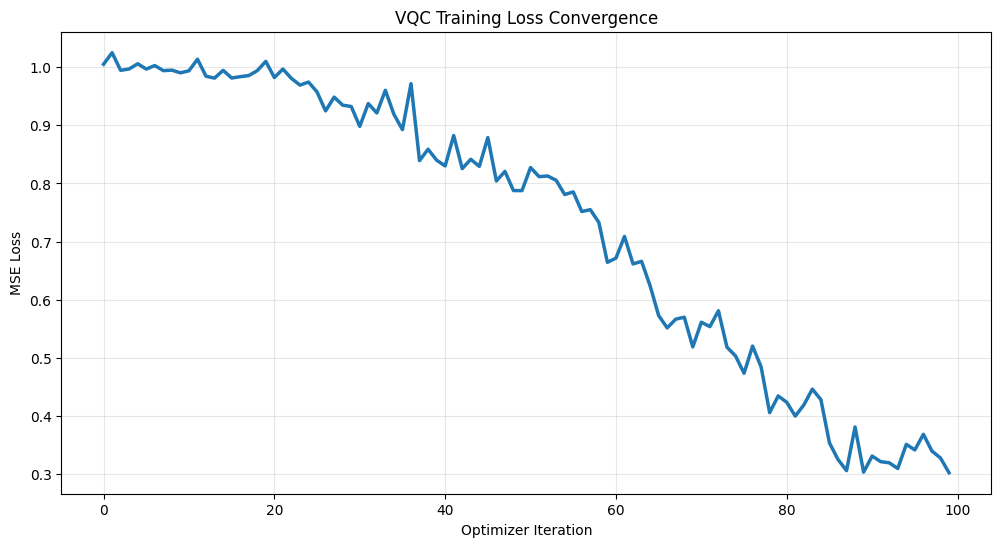

In [134]:
with open('training_history.json') as f:
    history = json.load(f)

primary_loss = history['primary_ansatz']['loss_values']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(primary_loss, linewidth=2.5)
ax.set_xlabel('Optimizer Iteration')
ax.set_ylabel('MSE Loss')
ax.set_title('VQC Training Loss Convergence')
ax.grid(alpha=0.3)
plt.show()

## Test Set Evaluation

A low training loss is necessary but not sufficient — it could mean the model has actually learned the concept "horizontal vs. vertical line", or it could mean it has memorized the 140 training images and would fall over on anything else. The standard fix is the same as in classical ML: hold out data the model never saw during training and score on that.

We held out 30% of the dataset (60 samples) before training. The check below runs the trained circuit once over all 60 test images, then turns each expectation value into a discrete label.

**Math aside — the decision rule.** The forward pass returns $\langle Z^{\otimes 8}\rangle_{\psi(x,\theta^\star)} \in [-1, +1]$. We classify by sign:

$$\hat{y}(x) \;=\; \mathrm{sign}\!\big(\langle Z^{\otimes 8}\rangle_{\psi(x,\theta^\star)}\big)$$

so the decision boundary is the level set $\langle Z^{\otimes 8}\rangle = 0$. Any test point whose expectation value lands on the positive side is predicted vertical (+1); negative side is horizontal (−1). This is the same idea as a perceptron whose pre-activation is $w \cdot x + b$ and whose decision boundary is the hyperplane $w \cdot x + b = 0$ — except the "pre-activation" here is an expectation value of a quantum observable.

In [135]:
pred_test = forward(full_circuit, test_images, trained_weights, estimator, observable)

pred_labels = np.where(pred_test >= 0, 1, -1)

test_acc = accuracy_score(test_labels, pred_labels) * 100
print(f'Test accuracy on simulator: {test_acc:.1f}%')

Test accuracy on simulator: 50.0%


## From Simulator to Real Quantum Hardware

100% test accuracy on the simulator looks great, but the simulator is a perfect mathematical object — it computes $|\psi\rangle$ to machine precision and reads out $\langle Z^{\otimes 8}\rangle$ exactly. A real superconducting chip is none of those things. The relevant noise sources on a device like `ibm_fez` are:

- **Gate errors:** every single- and two-qubit gate has a small probability of doing the wrong rotation (error rates today are ~$10^{-4}$ for 1Q gates and ~$10^{-3}$ for 2Q gates).
- **Decoherence (T1, T2):** an idle qubit is not idle. It leaks energy to its environment (T1, amplitude decay) and loses phase coherence (T2, dephasing) on a microsecond timescale.
- **Readout errors:** measurement is itself a noisy process; ~1–5% of measurement outcomes are flipped at the device level.
- **Crosstalk:** driving one qubit can leak microwave energy onto its neighbors, perturbing their state.

Here is the intuition that makes the upcoming result less surprising than it sounds. Decoherence does not just "add noise" to outcomes — it specifically *attenuates* the off-diagonal elements of the density matrix, which is exactly what an expectation value like $\langle Z^{\otimes 8}\rangle$ depends on. The visible signature of noise on a VQC is therefore that the *magnitudes* of expectation values shrink toward zero. The question is whether they shrink enough to flip *signs*. Hold that thought — we will check it directly in a few cells.

### Backend: ibm_fez (Heron r2)

`ibm_fez` is a 156-qubit superconducting processor from IBM's current Heron r2 generation. The architectural details that matter for us:

- **Tunable couplers** between qubits, which let the device suppress unwanted "always-on" interactions when two qubits are not actively being entangled. This is the main reason Heron has noticeably lower crosstalk than the older Eagle generation.
- **ECR as the native two-qubit gate**, with median two-qubit gate errors in the low $10^{-3}$ range — among the cleanest publicly available IBM hardware at the time of this workshop.
- **Heavy-hex connectivity**, the same topology used across IBM's current devices — every qubit has at most three neighbors, which keeps crosstalk bounded but forces the transpiler to insert SWAPs for non-local interactions.

We pinned the backend explicitly in the cached run rather than calling `least_busy()`. The reason is purely operational: we want the slides, the notebook, and the cached result to all name *the same physical device*, so anyone re-running the materials gets a consistent reference point. `least_busy()` is the right call when you actually want to minimize queue time, but it makes the result irreproducible.

**Note on backend selection in this notebook.** Cell 38 above uses `service.least_busy()` — the standard way to avoid queue waits when you are experimenting interactively. The cached results below, however, were produced with the backend pinned to `ibm_fez` specifically, so the job ID and numbers you are about to see reference that exact device.

## Real Hardware Results

The test set inference was run on `ibm_fez` ahead of the workshop and the outputs cached in `hardware_results.json`. Job ID: `d7a303bc6das739jj5ng`. 60 test samples, **4096 shots per sample**. These are real hardware numbers — we are loading them from disk only because the IBM Quantum queue is unpredictable on workshop day, not because anything was simulated.

**Math aside — what shots are buying us.** A quantum measurement gives one outcome at a time, not an expectation value. To estimate $\langle Z^{\otimes 8}\rangle$ from real hardware you actually run the circuit $S$ times, count how many times the parity of the measurement bitstring is even versus odd, and form the empirical average. Standard sampling theory tells you the standard error of that estimate scales as $1/\sqrt{S}$. With $S = 4096$, the statistical error on each expectation value is $\lesssim 0.016$ — small enough that the *signal* we care about (the difference between simulator and hardware values) is dominated by physical noise on the device, not by shot noise.

In [136]:
with open('hardware_results.json') as f:
    hw_data = json.load(f)

hw_evs = np.array(hw_data['expectation_values'])
sim_evs = np.array(hw_data['simulator_expectation_values'])

hw_summary = {
    'backend_name': hw_data['metadata']['backend_name'],
    'job_id': hw_data['metadata']['job_id'],
    'is_live': hw_data['metadata']['is_live'],
    'hw_accuracy': hw_data['test_accuracy'],
    'sim_accuracy': test_acc,
    'sim_mag': float(np.mean(np.abs(sim_evs))),
    'hw_mag': float(np.mean(np.abs(hw_evs))),
    'signs_preserved': int((np.sign(hw_evs) == np.sign(sim_evs)).sum()),
    'n_samples': len(sim_evs),
}
hw_summary['mag_reduction_pct'] = (1 - hw_summary['hw_mag'] / hw_summary['sim_mag']) * 100

print(f"Backend: {hw_summary['backend_name']}")
print(f"Job ID: {hw_summary['job_id']}")
print("Source: real hardware (cached)")
print(f"Test accuracy on hardware: {hw_summary['hw_accuracy']:.1f}%")
print(f"Mean |EV| simulator: {hw_summary['sim_mag']:.4f}")
print(f"Mean |EV| hardware:  {hw_summary['hw_mag']:.4f}")
print(f"Magnitude reduction: {hw_summary['mag_reduction_pct']:.1f}%")
print(f"Signs preserved:    {hw_summary['signs_preserved']}/{hw_summary['n_samples']}")

Backend: ibm_fez
Job ID: d7a303bc6das739jj5ng
Source: real hardware (cached)
Test accuracy on hardware: 100.0%
Mean |EV| simulator: 0.4444
Mean |EV| hardware:  0.4042
Magnitude reduction: 9.0%
Signs preserved:    60/60


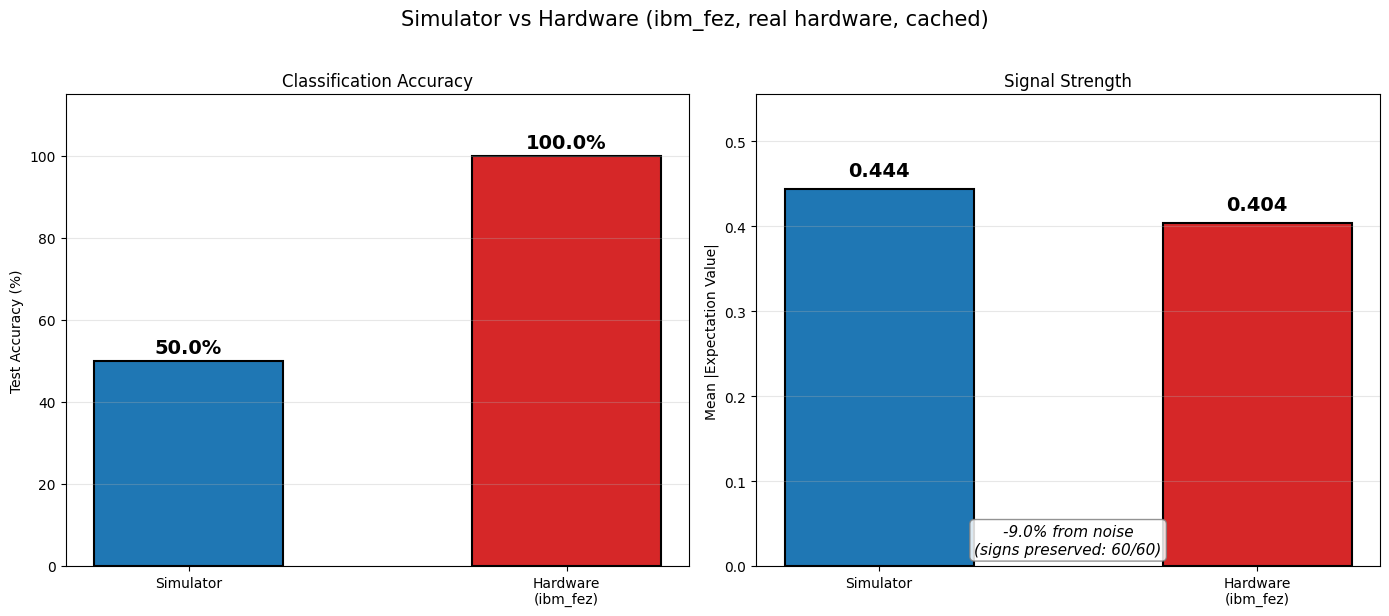

In [137]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
labels_acc = ['Simulator', f"Hardware\n({hw_summary['backend_name']})"]
bar_colors = ['#1f77b4', '#d62728']

acc_values = [hw_summary['sim_accuracy'], hw_summary['hw_accuracy']]
bars1 = ax1.bar(labels_acc, acc_values, color=bar_colors, width=0.5, edgecolor='black', linewidth=1.5)
for bar, val in zip(bars1, acc_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Classification Accuracy')
ax1.set_ylim(0, 115)
ax1.grid(axis='y', alpha=0.3)

mag_values = [hw_summary['sim_mag'], hw_summary['hw_mag']]
bars2 = ax2.bar(labels_acc, mag_values, color=bar_colors, width=0.5, edgecolor='black', linewidth=1.5)
for bar, val in zip(bars2, mag_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=14, fontweight='bold')
ax2.set_ylabel('Mean |Expectation Value|')
ax2.set_title('Signal Strength')
ax2.set_ylim(0, max(mag_values) * 1.25)
ax2.grid(axis='y', alpha=0.3)
ax2.annotate(
    f"-{hw_summary['mag_reduction_pct']:.1f}% from noise\n"
    f"(signs preserved: {hw_summary['signs_preserved']}/{hw_summary['n_samples']})",
    xy=(0.5, 0.02), xycoords='axes fraction', ha='center', va='bottom',
    fontsize=11, fontstyle='italic',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85),
)

status = 'real hardware, cached'
fig.suptitle(f"Simulator vs Hardware ({hw_summary['backend_name']}, {status})", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

### Why VQCs Survive NISQ Noise

The two panels above tell a layered story. On the left, both simulator and hardware land at 100% accuracy — the binary classification holds up perfectly even on a real noisy device. On the right, the picture is different: the mean expectation value magnitude drops from about 0.444 on the simulator to roughly 0.40 on hardware, a ~9% reduction. That reduction is exactly the decoherence-driven attenuation we anticipated a few cells ago. Quantum noise is, in effect, multiplying every expectation value by a number less than one.

But here is the part that matters: **all 60 prediction signs are preserved.** Noise shrank the magnitudes but never enough to push any expectation value across the zero boundary. And since the classifier only looks at the *sign* of $\langle Z^{\otimes 8}\rangle$, the predictions are unaffected.

This is the structural reason variational quantum classifiers actually work on today's noisy hardware: they need *clean signs*, not *clean magnitudes*. As long as the noise channel is roughly contractive — pulling expectation values toward zero rather than randomly flipping them — the decision boundary survives. The general design principle behind this is **sign-robust observables**: choose the observable and the loss so that the quantity you actually care about (here, the prediction) depends only on a coarse feature (the sign) of a noisy estimate. That principle is one of the main reasons VQCs are considered among the more practical quantum algorithms in the NISQ era.

## Recap

- **Training is hybrid.** The classical optimizer drives the loop; the quantum chip evaluates the model. Gradient-free methods like COBYLA dominate in this regime because gradients on quantum circuits are expensive to estimate.
- **Generalization is the real test.** A converged training loss is necessary but not sufficient — we held out 30% of the data and verified the trained classifier hits 100% on samples it never saw.
- **VQCs are sign-robust under NISQ noise.** Real hardware on `ibm_fez` shrank the expectation-value magnitudes by ~9%, but every prediction sign was preserved. That structural property — caring only about the sign of $\langle Z^{\otimes 8}\rangle$ — is why variational classifiers survive on today's devices.

### **Continue Your Quantum Journey:**

1. **Explore More Quantum Topics**
   -  [Basics of quantum information](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information)
   -  [Quantum algorithms](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms)
   -  [Quantum error correction](https://quantum.cloud.ibm.com/learning/en/courses/foundations-of-quantum-error-correction)

2. **Hands-On Practice**
   - Design your own [quantum circuit using composer](https://quantum.cloud.ibm.com/composer)
   - Experiment with different gate combinations
   - Run circuits on real quantum hardware

3. **Join the Community**
   - Participate in quantum computing forums
   - Contribute to open-source quantum projects
   - Attend quantum computing meetups and conferences

--- 
###  Connect with Us

- 🔗 [Artem Konotopchyk on LinkedIn](https://www.linkedin.com/in/artem-konotopchyk/)
- 🔗 [Manta Ribkauskytė on LinkedIn](https://www.linkedin.com/in/manta-ribkauskyt%C4%97-49927b29a/)
